# Exploratory Data Analysis — COVID-19 Policy Measures & Mobility

In this section, I start by loading the merged dataset and inspecting its basic structure.
The goal is to understand how many observations and variables are available, which countries
are included, and the overall time coverage before moving on to mobility–policy analysis.

The dataset mainly contains mobility percentage changes and government policy indicators for multiple countries across the COVID-19 period.

**EDA Roadmap — What I do in this section**
1. **Load and inspect the dataset** — check shape, variables, country coverage, and first rows.
2. **Identify and handle missing values** — remove or document variables with insufficient data quality.
3. **Explore global mobility trends over time** — visualize broad mobility shifts with stringency context.
4. **Explore associations between policy indicators and mobility sectors** — descriptive Spearman correlation heatmap across C1–C8 and mobility categories.
5. **Examine spillover & co-movement between mobility sectors** — descriptive scatterplots and correlations to observe whether sectors move together (no causal interpretation).
6. **Cross-country comparison of policy–mobility relationships** — compute and visualize country-level correlation differences.


## 1 — Load Data & Basic Dataset Overview

In this step, I load the merged COVID-19 mobility and policy dataset and take an initial look at its structure.  
The aim is to see how many observations and variables are available, which countries are included, and to verify that the dataset was merged correctly before continuing with further analysis.

In [9]:
import pandas as pd

df = pd.read_csv("covid_merged_final.csv")

print("Shape:", df.shape)
display(df.head(5))

print("\nColumn names:")
print(list(df.columns))

Shape: (3872, 21)


,countrycode,country,date,retail,grocery,parks,transit,workplaces,residential,stringencyindex,...,c2_workplace_closing,c3_cancel_public_events,c4_restrictions_on_gatherings,c5_close_public_transport,c6_stay_at_home_requirements,c7_restrictions_on_internal_movement,c8_international_travel_controls,e1_income_support,confirmedcases,confirmeddeaths
0,BR,Brazil,2020-02-15,5.0,4.0,-5.0,8.0,6.0,0.0,11.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,BR,Brazil,2020-02-16,2.0,3.0,-13.0,3.0,0.0,1.0,11.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,BR,Brazil,2020-02-17,-2.0,0.0,-12.0,9.0,19.0,-1.0,11.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,BR,Brazil,2020-02-18,-3.0,-1.0,-11.0,9.0,15.0,-1.0,11.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,BR,Brazil,2020-02-19,-1.0,-2.0,-5.0,8.0,14.0,-1.0,11.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN



Column names:
['countrycode', 'country', 'date', 'retail', 'grocery', 'parks', 'transit', 'workplaces', 'residential', 'stringencyindex', 'c1_school_closing', 'c2_workplace_closing', 'c3_cancel_public_events', 'c4_restrictions_on_gatherings', 'c5_close_public_transport', 'c6_stay_at_home_requirements', 'c7_restrictions_on_internal_movement', 'c8_international_travel_controls', 'e1_income_support', 'confirmedcases', 'confirmeddeaths']


In [10]:
# --- Countries included in the dataset ---

num_countries = df["country"].nunique()
countries = sorted(df["country"].unique())

print(f"Countries in dataset ({num_countries}):")
print(", ".join(countries))

Countries in dataset (11):
Brazil, France, Germany, Italy, Japan, South Korea, Spain, Sweden, Turkey, United Kingdom, United States


## 2 - Missing values and column adjustment

Here I check missing values across the dataset and remove the column with high percentage of NAN values, which will alter the results of the project or create unreliable outcomes. 

In [11]:
# STEP 1.2 — Missing values summary

missing_summary = (
    df.isna().sum()
      .reset_index()
      .rename(columns={"index":"column", 0:"missing_count"})
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
).round(2)

display(missing_summary.sort_values("missing_percent", ascending=False))


,column,missing_count,missing_percent
19,confirmedcases,2801,72.34
20,confirmeddeaths,1096,28.31
11,c2_workplace_closing,0,0.00
18,e1_income_support,0,0.00
17,c8_international_travel_controls,0,0.00
16,c7_restrictions_on_internal_movement,0,0.00
15,c6_stay_at_home_requirements,0,0.00
14,c5_close_public_transport,0,0.00
13,c4_restrictions_on_gatherings,0,0.00
12,c3_cancel_public_events,0,0.00


In [12]:
# Because this level of missingness may bias the results and cannot be reliably imputed,
# it is removed from the analysis.
df = df.drop(columns=["confirmedcases"]) 

## 3 - Global Mobility Response to Government Stringency

In this step, I compute the weekly global average of the six mobility indicators
and compare them with the average government stringency index over time.
Aggregating the data to weekly frequency smooths out daily noise and helps reveal
the broader mobility response patterns during the pandemic period.

Weekly averages are calculated as unweighted country means, meaning each country contributes equally to the global trend rather than being weighted by population.

Weekly shape: (51, 8)


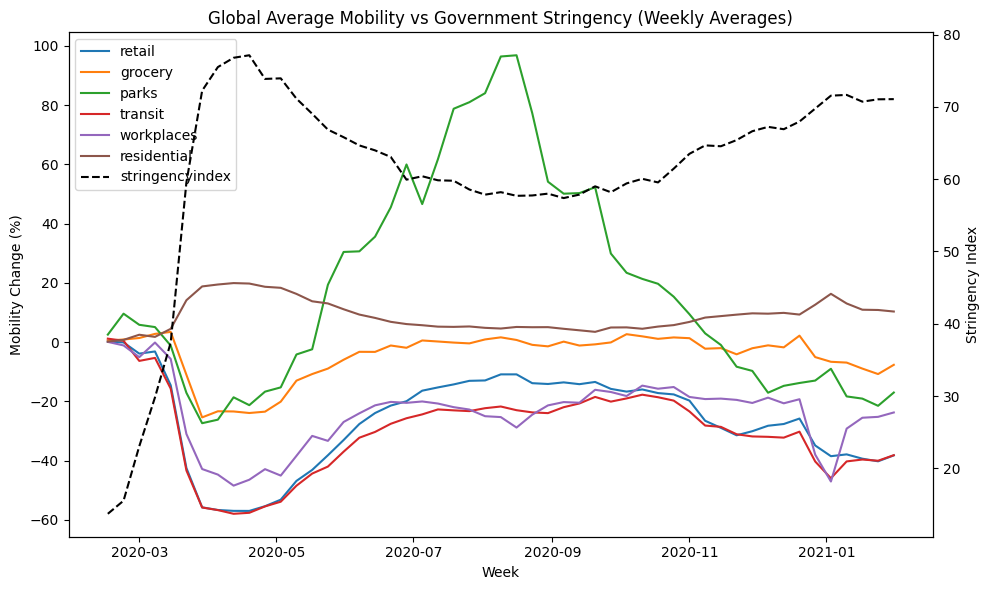

In [18]:
# STEP 2 (Weekly) — Global Average Mobility vs Government Stringency

import pandas as pd
import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])

mobility_cols = ["retail","grocery","parks",
                 "transit","workplaces","residential"]

# compute weekly averages across countries
weekly = (
    df.groupby(pd.Grouper(key="date", freq="W"))[
        mobility_cols + ["stringencyindex"]
    ]
    .mean()
    .reset_index()
)

print("Weekly shape:", weekly.shape)

# ---- plot ----
fig, ax1 = plt.subplots(figsize=(10,6))

for col in mobility_cols:
    ax1.plot(weekly["date"], weekly[col], label=col)

ax1.set_ylabel("Mobility Change (%)")
ax1.set_xlabel("Week")
ax1.set_title("Global Average Mobility vs Government Stringency (Weekly Averages)")

# secondary axis for stringency
ax2 = ax1.twinx()
ax2.plot(weekly["date"], weekly["stringencyindex"],
         color="black", linestyle="--", label="stringencyindex")
ax2.set_ylabel("Stringency Index")

# combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

***Interpretation:***

From the plot, we see a sharp drop in workplace, retail, grocery, and transit mobility around March 2020, matching the first lockdown period, while residential mobility increases and stays above baseline. Around mid-2020, park mobility rises immensely, suggesting people shifted activity outdoors, and this period also overlaps with a sharp increase in the stringency index.

Later in the pandemic, the drop in mobility becomes weaker compared to the first lockdown period, which may reflect behavioral adaptation over time, although this cannot be interpreted causally from the data.

## 4 - Policy Indicators vs Mobility Response (H1)

In this step, I look at how individual COVID-19 policy components (C1–C8 and E1) are
associated with different mobility categories.

Because H1 focuses on whether policies and mobility are related, here I first explore these associations descriptively using a Spearman correlation heatmap.

Policy columns: ['c1_school_closing', 'c2_workplace_closing', 'c3_cancel_public_events', 'c4_restrictions_on_gatherings', 'c5_close_public_transport', 'c6_stay_at_home_requirements', 'c7_restrictions_on_internal_movement', 'c8_international_travel_controls', 'e1_income_support']


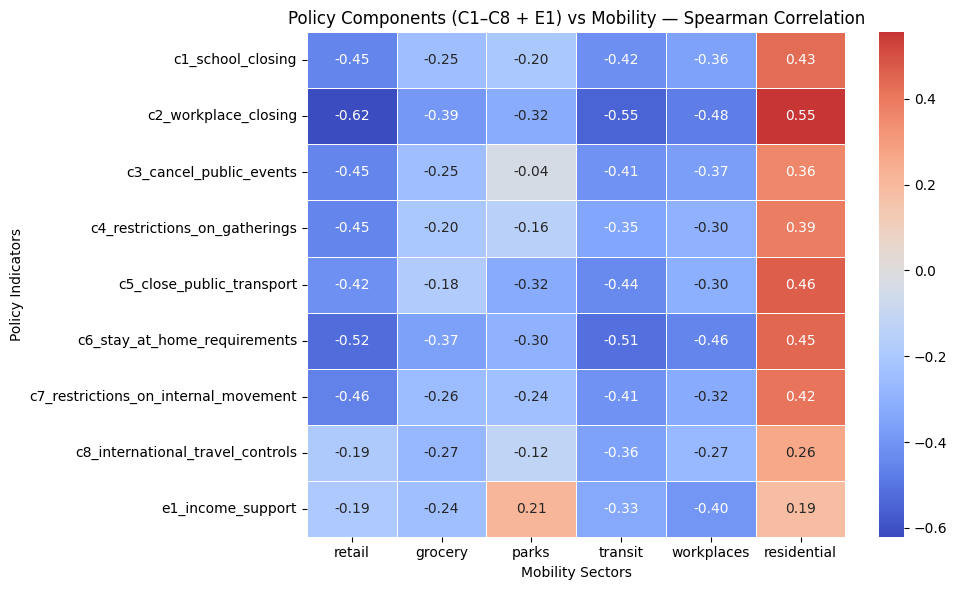

In [14]:
# STEP 3 — Policy Indicators vs Mobility — Spearman Correlation Heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# mobility columns (same set as before)
mobility_cols = ["retail","grocery","parks",
                 "transit","workplaces","residential"]

# select policy columns C1–C8 + E1 income support
policy_cols = [
    c for c in df.columns
    if c.lower().startswith(("c1_","c2_","c3_","c4_",
                             "c5_","c6_","c7_","c8_","e1_"))
]

print("Policy columns:", policy_cols)

# subset + numeric conversion
corr_df = df[policy_cols + mobility_cols].apply(pd.to_numeric, errors="coerce")

# compute Spearman correlations
corr_matrix = corr_df.corr(method="spearman")

# policy rows vs mobility columns only
corr_subset = corr_matrix.loc[policy_cols, mobility_cols]

# ---- plot heatmap ----
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_subset,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Policy Components (C1–C8 + E1) vs Mobility — Spearman Correlation")
plt.xlabel("Mobility Sectors")
plt.ylabel("Policy Indicators")
plt.tight_layout()
plt.show()

***Interpretation:***

The heatmap shows that stricter policies are mostly associated with lower mobility in retail, transit, and workplaces, which appears as negative (blue) correlations. Residential mobility shows the opposite pattern and tends to increase when policy indicators are higher. 

Parks mobility shows the weakest and most mixed relationship with policy indicators.

## 5 - Spillover Effects Across Mobility Sectors (H2)

In this step, I look at H2, which is about whether mobility sectors move together rather than
independently. For example, when workplace mobility decreases, retail or transit mobility may
also decrease in a similar direction. I explore this co-movement pattern using scatterplots and
Spearman correlations in a descriptive way.

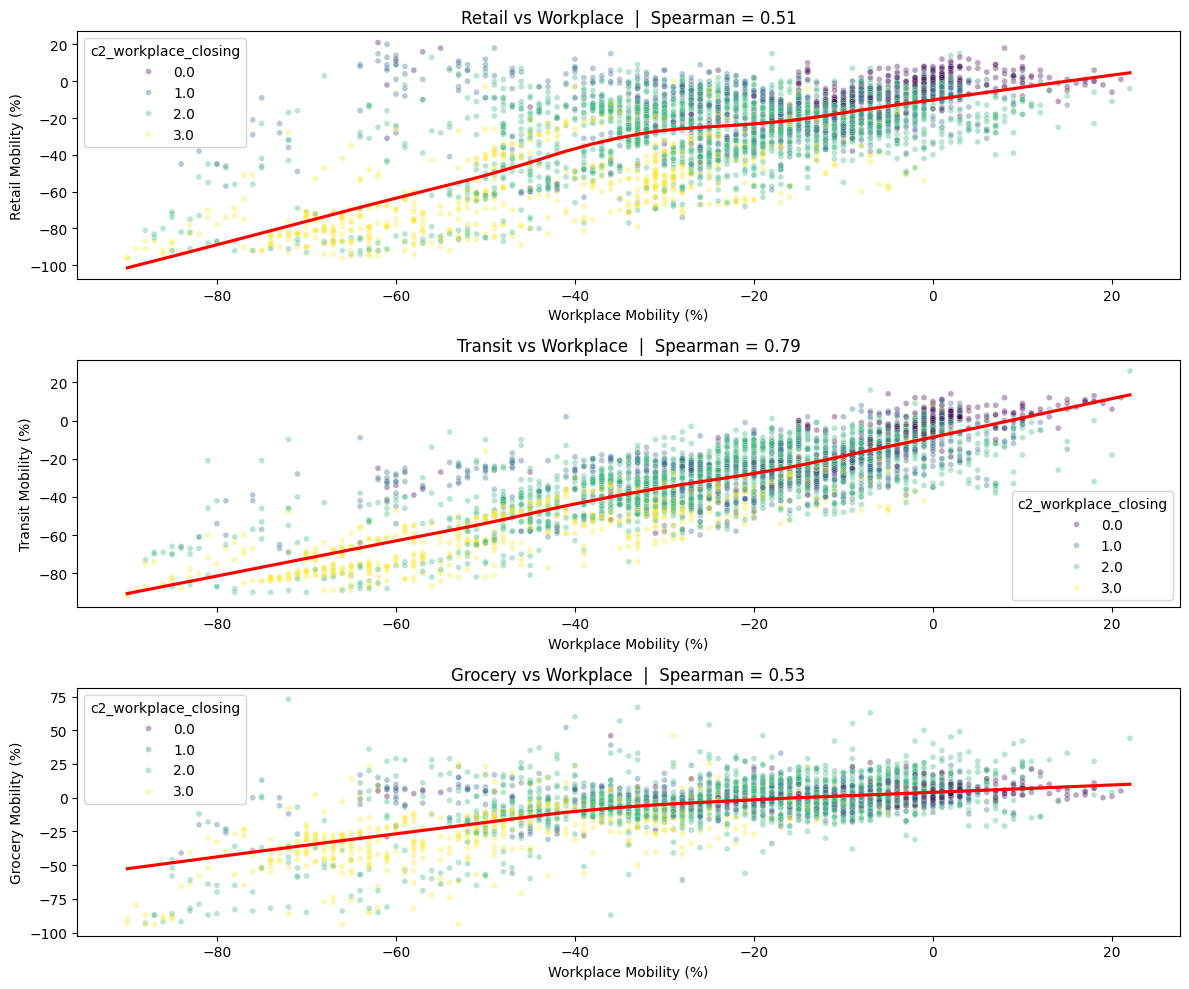

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

pairs = [
    ("retail",   "Retail vs Workplace"),
    ("transit",  "Transit vs Workplace"),
    ("grocery",  "Grocery vs Workplace")
]

plt.figure(figsize=(12, 10))

for i, (col, title) in enumerate(pairs, start=1):

    sub = df[["workplaces", col, "c2_workplace_closing"]].dropna()

    rho = spearmanr(sub["workplaces"], sub[col]).correlation

    plt.subplot(3,1,i)

    sns.scatterplot(
        data=sub,
        x="workplaces",
        y=col,
        hue="c2_workplace_closing",
        alpha=0.35,
        s=18,
        palette="viridis"
    )

    sns.regplot(
        data=sub,
        x="workplaces",
        y=col,
        scatter=False,
        lowess=True,
        color="red"
    )

    plt.title(f"{title}  |  Spearman = {rho:.2f}")
    plt.xlabel("Workplace Mobility (%)")
    plt.ylabel(f"{col.capitalize()} Mobility (%)")

plt.tight_layout()
plt.show()


***Interpretation:***

The positive Spearman correlations show that mobility changes across sectors move together rather than independently, meaning drops in workplace mobility are usually accompanied by drops in retail, transit, and grocery mobility. Higher C2 levels cluster in the lowest-mobility regions, indicating that stricter restriction periods are associated with larger joint mobility reductions — although this remains correlational, not causal.

## 6 - Cross-Country Comparison: Policy–Mobility Relationship (H3)

Here I explore country-level correlations between selected policy indicators and mobility outcomes to see whether the strength of the relationship varies across countries.

,country,spearman_corr
7,South Korea,0.157136
6,Japan,0.159093
9,Turkey,0.181348
5,Italy,0.216534
8,Sweden,0.253703
0,Brazil,0.370174
10,United States,0.596381
4,United Kingdom,0.622806
2,Spain,0.625196
1,Germany,0.727261


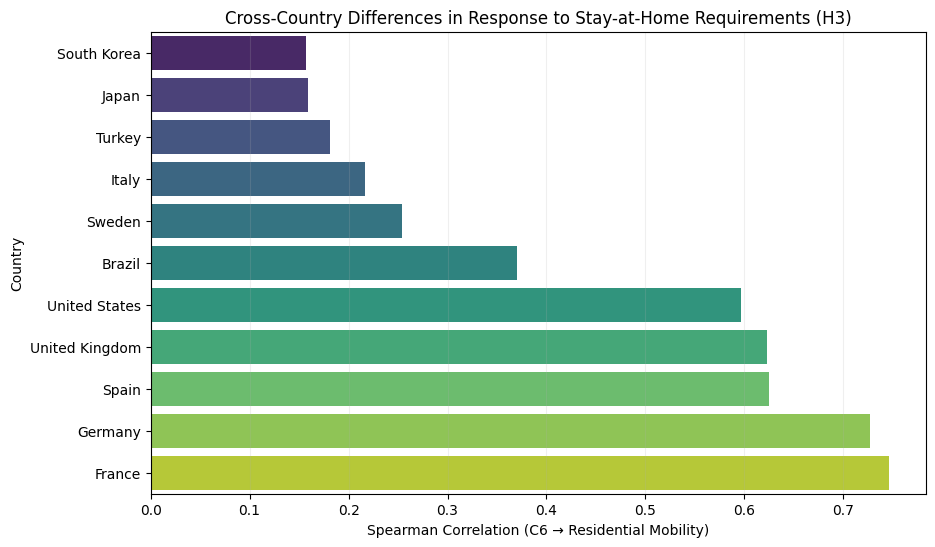

In [16]:
# STEP 5 — Cross-Country Comparison (H3)
# C6 Stay-at-Home Requirements → Residential Mobility

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ---- compute country-level Spearman correlations ----
country_corr = []

for c in df["country"].unique():

    sub = df[df["country"] == c]

    x = sub["c6_stay_at_home_requirements"]
    y = sub["residential"]

    mask = x.notna() & y.notna()
    x_clean = x[mask]
    y_clean = y[mask]

    if len(x_clean) > 3:     # avoid tiny samples
        rho = spearmanr(x_clean, y_clean).correlation
        country_corr.append((c, rho))

country_corr_df = (
    pd.DataFrame(country_corr, columns=["country","spearman_corr"])
      .sort_values("spearman_corr")
)

display(country_corr_df)


# ---- seaborn 0.14+ safe barplot (no warnings) ----
plt.figure(figsize=(10,6))

sns.barplot(
    data=country_corr_df,
    x="spearman_corr",
    y="country",
    hue="country",          # map palette to hue to satisfy new API
    palette="viridis",
    legend=False            # hide duplicate legend
)

plt.xlabel("Spearman Correlation (C6 → Residential Mobility)")
plt.ylabel("Country")
plt.title("Cross-Country Differences in Response to Stay-at-Home Requirements (H3)")
plt.grid(axis="x", alpha=0.2)

plt.show()


***Interpretation:***

The results show that the strength of the relationship between stay-at-home requirement (C6) and residential mobility differs across countries meaning some populations increased time spent at home much more than others under similar policies, incidating cross-country variation in behavioral compliance.

# Conclusion

The EDA shows that mobility changes during COVID-19 are closely associated with government policies, but the associations differ across policy types and mobility sectors. Some policies (c2 - workplace closure,c6 - stay home requirements) are linked  to stronger mobility reductions than others.

Mobility sectors also tends to move together rather than in an isolated way.

At the same time, the potency of these policy-mobility relationships varies across countries - especially for C6 and residential mobility - suggesting that similar policies can lead to different behavioral responses across different countries.